# Code-Übung 2: Finite-Differenzen-Methode
Themen dieser Übung sind:

* Vorwärtsdifferenzen
* Zentraldifferenzen
* 3-Punkt-Zentraldifferenzen
* Konvergenzanalyse

## 1D-Finite-Differenzen: Der Kragarm 
Gegeben sein ein Kragarm mit einer allgemeinen Linienlast $q(x)$ und der eingeprägten Kraft $F$ am freien Ende. Der Balken habe einen kreisförmigen Querschnitt mit dem Durchmesser $d(x)$. Außerdem sei der E-Modul $E = 1 \cdot 10^5 \frac{N}{m^2}$ gegeben. Gesucht sind der Querkraftverlauf $Q(x)$, der Biegemomentenverlauf $M(x)$ und die Durchbiegung $w(x)$.

<img src="./graphics/Kragarm.png" style="width: 50%;">

Die Differentialgleichung der Biegeline lautet insgesamt:
$$
\frac{d^2}{dx^2}\Bigl(EI(x)\frac{d^2 w(x)}{dx^2}\Bigr) = q(x).
$$
Hierbei ist $I(x)$ das Flächenträgheitsmoment
$$
I(x) = \frac{\pi (d(x))^4}{64}.
$$
Bei Betrachtung von Teilschritten erhält man Gleichungen für Querkraft und Biegemoment:
\begin{align*}
\frac{dQ(x)}{dx} &= - q(x)\\
\frac{dM(x)}{dx} &= Q(x)\\
\frac{d^2 w(x)}{dx^2}  &= \frac{-M(x)}{EI(x)}
\end{align*}

Die Randbedingungen im Falle des Kragarms lauten:
$$
Q(x=L) = F, \;\; M(x=L) = 0, \;\; \frac{dw(x)}{dx}(x=0) = 0, \;\; w(x=0) = 0
$$

## Analytische Lösung

Sind $E$ und $I$ konstant in $x$, so vereinfacht sich die Differentialgleichung der Biegeline zu
$$
EI\frac{d^4 w(x)}{dx^4} = q(x).
$$
Durch Integration unter Berücksichtigung der Randbedingungen kann eine analytische Lösung für $w(x)$ hergeleitet werden. Wirkt beispielsweise nur die Kraft $F$ an der Spitze und $q=0$, so ist die Biegelinie gegeben durch
$$
w(x) = -\frac{F}{6EI} x^3 + \frac{FL}{2EI} x^2
$$

## Numerische Lösung
Zur Lösung mittels der Finite-Differenzen-Methode (FDM) werden diskrete Punkte entlang des Balkens betrachtet:

<img src="./graphics/Diskretisierung.png" style="width: 50%;">

Im Folgenden wird das Randwertproblem schrittweise durch numerische Berechnung der Querkraft, des Momentes sowie anschließend der Biegelinie gelöst. Hierbei kommen jeweils verschiedene Finite Differenzen zum Einsatz.


### Import

In [169]:
import sys
import numpy as np
from scipy.linalg import solve

# import helper functions, depending on whether we are running in Google Colab or not

IN_COLAB = "google.colab" in sys.modules # check if we are running in Google Colab (if module exists, we are)

if IN_COLAB:
    # clone the repository to access the helper functions (the version on the main branch)
    !git clone https://github.com/CPShub/LectureNSM.git 
    from LectureNSM.ex2_finite_differences.helper_functions import plot_force, plot_deflection, plot_convergence
    %rm -rf LectureNSM  # delete the folder after importing, to enable re-importing if we run the cell again

else:
    from helper_functions import plot_force, plot_deflection, plot_convergence


### Modellparameter

In [170]:
N = 11                                          # number of points
L = 1                                           # length of the cantilever in m
q = 0                                           # line load in N/m
F = 1                                           # load at the tip of the cantilever in N
E = 1e5                                         # Youngs modulus in N/m^2

delta_x = L/(N-1)                               # Step size in m
x_axis = np.linspace(0, L, N)                   # x-positions to be evaluated in m
d = 0.1*np.ones((1,N))                          # Beam diameter at every x-position to be evaluated in m    
# d(7) = 0.05
d = 0.15-x_axis*0.1                          # Variable diameter of the beam in m
print(d)

I = np.array([np.pi/64*d_val**4 for d_val in d])    # Moment of inertia at every x-position to be evaluated in m^4

[0.15 0.14 0.13 0.12 0.11 0.1  0.09 0.08 0.07 0.06 0.05]


### Querkraft (Vorwärtsdifferenzen)
Für den Zusammenhang zwischen der Linienlast $q(x)$ und der Querkraft $Q(x)$ gilt folgender Ausdruck
$$
\frac{dQ(x)}{dx} = - q(x)
$$
Dieser wird mittels Vorwärtsdifferenzen diskretisiert:
$$
\frac{Q_{i+1} - Q_i}{\Delta x} = - q_i
$$
Auflösen nach den unbekannten Knotenwerten:
$$
- Q_i + Q_{i+1} = - q_i \Delta x
$$
Dies liefert eine Gleichung je betrachtetem Punkt $i$. Der letzte betrachtete Punkt $N$ an der Stelle $x=L$ ist als Sonderfall zu betrachten, da der "darauffolgende" Punkt $Q_{N+1}$ außerhalb des Gitters liegt. Dadurch fällt eine Gleichung weg, die jedoch durch die Randbedingung ausgeglichen wird. Diese ist gegeben als die eingeprägte Kraft $F$. Es gilt:
$$
Q(x=L) = Q_{N} = F
$$
Betrachten aller Punkte $i$ führt auf ein lineares Gleichungssystem, wobei jede Zeile die Berechnung an einem Punkt repräsentiert und die Randbedingung in der letzten Zeile berücksichtigt ist:
$$
\begin{bmatrix}
    -1 & 1 & 0 & 0 & ... & 0\\
    0 & -1 & 1 &  0 & ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    0 & ...  & ... & 0 & 0 & 1\\
\end{bmatrix}
\cdot
\begin{bmatrix}
Q_1 \\
Q_2 \\
\vdots \\
Q_N
\end{bmatrix}
= 
\begin{bmatrix}
- q_1 \Delta x\\
- q_2 \Delta x\\
\vdots\\
F
\end{bmatrix}
$$

[[ 1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  1. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.]]


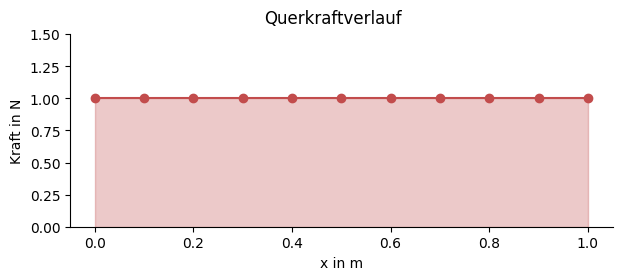

In [171]:
# Assembling the coefficient matrix
K = np.zeros((N, N))
for idx in range(N):
    K[idx][idx] = 1          # Major diagonal
    
    if idx+1 < N:
        K[idx][idx+1] = - 1  # Minor diagonal

# Calculating the RHS vector
f = np.array([-q * delta_x for idx in range(N)])

# Adding the boundary condition
f[-1] = F

print(K)

# Solving the system of equations
Q = solve(K, f)

plot_force(x_axis, Q, "Querkraftverlauf", "Kraft in N")


### Biegemoment (Zentraldifferenzen)
Für den Zusammenhang zwischen der Querkraft $Q(x)$ und dem Biegemoment $M(x)$ gilt folgender Ausdruck
$$
\frac{dM(x)}{dx} = Q(x)
$$
Dieser wird mittels Zentraldifferenzen diskretisiert:
$$
\frac{M_{i+1} - M_{i-1}}{2 \Delta x} = Q_i
$$
Auflösen nach den unbekannten Knotenwerten
$$
-M_{i-1} + M_{i+1} = 2 \Delta x Q_i\\
$$
Die Punkte $i = 1$ und $i = N$ müssen gesondert betrachtet werden, da hier jeweils der Wert $M_{i-1}$ bzw. $M_{i+1}$ außerhalb des Gitters liegt. Hierdurch fallen zwei Gleichungen (Zeilen in der Matrix) weg, sodass das LGS zunächst unterbestimmt ist. Die erste Bedinung kann jedoch wie zuvor wieder mittels einer Randbedingung hinzugefügt werden.
$$
M(x=L) = M_{N} = 0\\
$$
Die zweite Gleichung kann "aufgefüllt" werden, indem der letzte Punkt mittels Rückwärtsdifferenzen betrachtet wird.
$$
\frac{M_N-M_{N-1}}{\Delta x} = Q_N\\
$$
Auflösen nach den Knotenwerten ergibt:
$$
- M_{N-1} + M_N = Q_N \Delta x
$$
Unter Einbezug der Randbedingung und der Rückwärtsdifferenzen als zusätzliche Gleichungen, entsteht folgendes Gleichungssystem:
$$
\begin{bmatrix}
    0 & 0 & 0 & 0 & ... & 1\\
    -1 & 0 & 1 & 0 & ... & 0\\
    0 & -1 & 0 & 1 &  ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    0 & ...  & ... & 0 & -1 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
M_1 \\
M_2 \\
M_3\\
\vdots \\
M_N
\end{bmatrix}
=
\begin{bmatrix}
0\\
2 Q_2\Delta x\\
2 Q_3 \Delta x\\
\vdots\\
Q_N \Delta x
\end{bmatrix}
$$

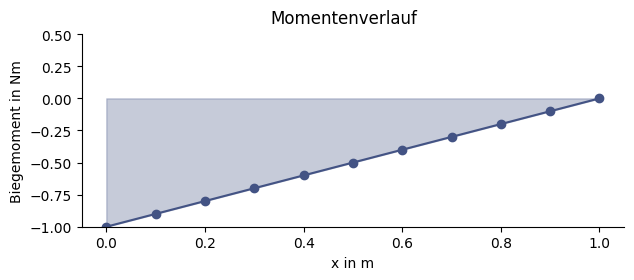

In [172]:
# Assembling the coefficient matrix
K = np.zeros((N, N))
for idx in range(1, N-1):           # Note: First and last rows are omitted
    K[idx][idx+1] = 1     # First minor diagonal
    
    if idx > 0:
        K[idx][idx-1] = - 1  # Second minor diagonal

# Calculating the RHS vector
f = np.array([2 * delta_x * Q[idx] for idx in range(N)])

# Boundary condition at the right end
K[0, -1] = 1
f[0] = 0

# Backward difference at the right end
K[-1][-1] = 1
K[-1][-2] = -1
f[-1] = delta_x * Q[N-1]

# Solving the system of equations
M = solve(K, f)

plot_force(x_axis, M, "Momentenverlauf", "Biegemoment in Nm")


### Biegelinie (3-Punkt-Zentraldifferenz)
In dieser Aufgabe wird direkt die zweite Ableitung diskretisiert. Für den Zusammenhang zwischen der Durchbiegung $w(x)$ und dem Biegemoment $M(x)$ gilt folgender Ausdruck
$$
\frac{d^2 w(x)}{dx^2} EI(x) = -M(x)
$$
Die Verschiebung $w(x)$ wird mittels der 3-Punkt-Zentraldifferenz diskretisiert:
$$
\frac{w_{i-1} - 2 w_i + w_{i+1}}{\Delta x^2} EI_i = -M_i
$$
Auflösen nach den Knotenwerten:
$$
w _{i-1} -2 w_i + w_{i+1} = \frac{-M_i \Delta x^2}{E I_i}\\
$$
Die Punkte $i = 1$ und $i = N$ müssen gesondert betrachtet werden, da hier jeweils der Wert $w_{i-1}$ bzw. $w_{i+1}$ außerhalb des Gitters liegt. Hierdurch fallen zwei Gleichungen weg, sodass das LGS zunächst unterbestimmt ist. Im hier betrachteten Fall können jedoch beide Gleichungen mit Randbedingungen "aufgefüllt" werden. Zunächst die Dirichlet-Randbedingung:
$$
w(x=0) = w_{1} = 0\\
$$
Die Neumann-Randbedingung kann durch Approximieren der Ableitung am Rand durch die 3-Punkt-Vorwärtsdifferenz berücksichtigt werden:
$$
\frac{dw}{dx}\bigg\vert_{(x=0)}  = 0\\[2ex]
\frac{-3 w_1 + 4w_2 -w_3}{2 \Delta x} = 0
$$
Auflösen nach den Knotenwerten:
$$
-3 w_1 + 4w_2 -w_3 = 0
$$

Unter Einbezug der Randbedingungen entsteht folgendes Gleichungssystem:
$$
\begin{bmatrix}
    -3 & 4 & -1 & 0 & ... & 0\\
    1 & -2 & 1 & 0 & ... & 0\\
    0 & 1 & -2 & 1 &  ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    1 & ...  & ... & 0 & 0 & 0\\
\end{bmatrix}
\cdot
\begin{bmatrix}
w_1 \\
w_2 \\
w_3\\
\vdots \\
w_N
\end{bmatrix}
=
\begin{bmatrix}
0\\
-M_2 \Delta x^2 / E I_2\\
-M_3 \Delta x^2 / E I_3\\
\vdots\\
0
\end{bmatrix}
$$

[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1. -2.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -2.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1. -2.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. -2.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1. -2.  1.]
 [-3.  4. -1.  0.  0.  0.  0.  0.  0.  0.  0.]]


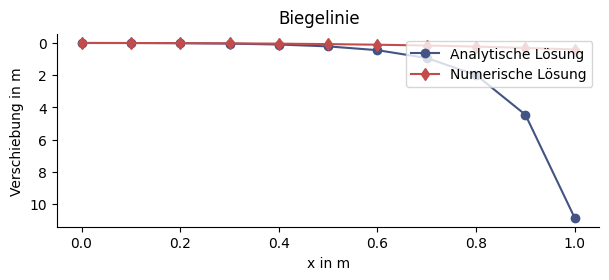

In [173]:
# Assembling the coefficient matrix
K = np.zeros((N, N))
for idx in range(1, N-1):           # Note: First and last rows are omitted
    K[idx][idx] = -2          # Major diagonal
    K[idx][idx+1] = 1     # First minor diagonal
    
    if idx > 0:
        K[idx][idx-1] = 1  # Second minor diagonal

# Calculating the RHS vector
f = np.array([-M[idx]*delta_x**2/(E*I[idx]) for idx in range(N)])

# Boundary condition w=0 at the left end
K[0, 0] = 1
f[0] = 0

# Boundary condition dw/dx=0 at the left end
K[-1][0] = -3
K[-1][1] = 4
K[-1][2] = -1
f[-1] = 0

print(K)

# Solving the system of equations
w = solve(K, f)

# Analytical solution
w_analytical = np.array([F*x**2/(6*E*I[idx])*(3*L-x) for idx, x in enumerate(x_axis)])

plot_deflection(x_axis, w, w_analytical, "Biegelinie", "Verschiebung in m")

## Konvergenzanalyse
Nun soll die Konvergenzordnung der gezeigten Verfahren betrachtet werden. Hierzu wird die Differentialgleichung 
$$
u(x) = \frac{df(x)}{dx}
$$
mit
$$
f(x) = \sin(x)
$$
gewählt. Die exakte Lösung ist als
$$
u_{exakt}(x) = \cos(x)
$$
bekannt. Die Konvergenzordnung kann basierend auf drei numerischen Lösungen $\Phi$ mit unterschiedlicher Schrittweite $h$ geschätzt werden:
$$
p = \log_2 \frac{\Phi _ {2h} - \Phi _{4h}}{\Phi _{h} - \Phi _{2h}}
$$


In [174]:
# For the actual calculation
step_sizes = [1e-4, 2e-4, 4e-4]
L = 1.2e-3
phi_fwd_sol = np.zeros((3, 1))
phi_central_1_sol = np.zeros((3, 1))
phi_central_2_sol = np.zeros((3, 1))

function = lambda x: np.exp(x)
phi0 = 1
analytical_solution = lambda x: np.exp(x)

for i, h in enumerate(step_sizes):

    N = int(L/h) + 1
    x_axis = np.linspace(0, L, N)

    # forward difference scheme
    K1 = np.zeros((N, N))
    for idx in range(N):
        K1[idx][idx] = 1          # Major diagonal
        
        if idx > 0:
            K1[idx][idx-1] = - 1  # Minor diagonal

    # RHS vector
    f = np.array([h * function(x_axis[idx]) for idx in range(N)])
    f[0] = phi0  # Boundary condition at the left end

    phi_fwd = solve(K1, f)
    phi_fwd_sol[i] = phi_fwd[-1]  # Store the solution at the right end

    # central difference scheme

    K2 = np.zeros((N, N))
    for idx in range(1, N-1):           # Note: First and last rows are omitted
        K2[idx][idx+1] = 1     # First minor diagonal
        
        if idx > 0:
            K2[idx][idx-1] = - 1  # Second minor diagonal

    # RHS vector
    f = np.array([2 * h * function(x_axis[idx]) for idx in range(N)])

    # BC at the left end
    K2[0][0] = 1
    f[0] = phi0

    # a) first-order forward difference at the right end
    K2[-1][-2] = - 1
    K2[-1][-1] = 1
    f[-1] = function(x_axis[-1])*h

    phi_central_1 = solve(K2, f)
    phi_central_1_sol[i] = phi_central_1[-1]  # Store the solution at the right end

    # b) second-order backward difference at the right end
    K2[-1][-3] = 1
    K2[-1][-2] = -4
    K2[-1][-1] = 3
    f[-1] = function(x_axis[-1])*2*h

    phi_central_2 = solve(K2, f)
    phi_central_2_sol[i] = phi_central_2[-1]  # Store the solution at the right end
    

print(phi_central_1_sol)
print(phi_central_2_sol)
print(phi_fwd_sol)


p = lambda phi_h, phi_2h, phi_4h: np.log2((phi_2h-phi_4h)/(phi_h-phi_2h))
p_fwd = p(phi_fwd_sol[0], phi_fwd_sol[1], phi_fwd_sol[2])
p_central_1 = p(phi_central_1_sol[0], phi_central_1_sol[1], phi_central_1_sol[2])
p_central_2 = p(phi_central_2_sol[0], phi_central_2_sol[1], phi_central_2_sol[2])

print(f"Die Vorwärtsdifferenz hat die geschätzte Konvergenzordnung p = {p_fwd}.")
print(f"Die Zentraldifferenz hat die geschätzte Konvergenzordnung p = {p_central_1}.")
print(f"Die zweite Zentraldifferenz hat die geschätzte Konvergenzordnung p = {p_central_2}.")


# plot_convergence(step_sizes, err_fds, err_cds, "Vorwärtsdifferenz", "Zentraldifferenz")


[[1.00110067]
 [1.00100062]
 [1.00080048]]
[[1.00110066]
 [1.0010006 ]
 [1.00080048]]
[[1.00110072]
 [1.00100072]
 [1.00080072]]
Die Vorwärtsdifferenz hat die geschätzte Konvergenzordnung p = [0.99999991].
Die Zentraldifferenz hat die geschätzte Konvergenzordnung p = [1.00044113].
Die zweite Zentraldifferenz hat die geschätzte Konvergenzordnung p = [1.00000023].
